# Un premier CNN sur CIFAR-10 avec PyTorch

Objectif : construire pas à pas un réseau convolutif simple pour classer les images de CIFAR-10 (10 classes, images RGB 32x32).

Étapes : données → visualisation → modèle → entraînement → courbes → évaluation sur le test.

## 1. Imports, device et seeds

On choisit automatiquement le meilleur matériel disponible : GPU NVIDIA (`cuda`), puis GPU Apple (`mps`), sinon `cpu`.
On fixe aussi les graines aléatoires (torch, numpy, random) pour que les résultats soient reproductibles (initialisation des poids, ordre des batchs, séparation train/val).

In [2]:
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Choix du device : cuda > mps > cpu
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device utilisé :', device)

# Seeds pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)  # fixe aussi la seed sur GPU (cuda et mps)

Device utilisé : cuda


## 2. Chargement de CIFAR-10 et normalisation

- `transforms.ToTensor()` convertit une image PIL (H, W, C) avec des valeurs entières dans [0, 255] en un tenseur (C, H, W) de flottants dans [0, 1].
- `transforms.Normalize(mean, std)` retire ensuite à chaque canal sa moyenne et divise par son écart-type : les entrées sont alors centrées et d'échelle ~1, ce qui facilite l'optimisation.

La moyenne et l'écart-type par canal (R, G, B) sont calculés **uniquement sur le jeu d'entraînement** (on ne doit jamais utiliser le test pour fixer un prétraitement). On les calcule directement à partir de `train_raw.data`, un tableau numpy de forme (50000, 32, 32, 3).

In [3]:
DATA_DIR = './data'

# 1) On charge une première fois le train, sans transformation, juste pour calculer les statistiques
train_raw = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
pixels = train_raw.data / 255.0               # (50000, 32, 32, 3), valeurs dans [0, 1]
mean = pixels.mean(axis=(0, 1, 2))            # une moyenne par canal -> forme (3,)
std = pixels.std(axis=(0, 1, 2))              # un écart-type par canal -> forme (3,)
print('Moyenne par canal :', mean)
print('Écart-type par canal :', std)

# 2) Pipeline de transformations appliqué à chaque image
transform = transforms.Compose([
    transforms.ToTensor(),                                   # [0, 255] -> [0, 1], (H, W, C) -> (C, H, W)
    transforms.Normalize(mean.tolist(), std.tolist()),       # (x - mean) / std, canal par canal
])

# 3) Jeux d'entraînement et de test avec cette transformation
full_train_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

classes = full_train_set.classes  # ['airplane', 'automobile', 'bird', ...]
print('Taille train complet :', len(full_train_set))
print('Taille test :', len(test_set))
print('Classes :', classes)

100.0%


Moyenne par canal : [0.49139968 0.48215841 0.44653091]
Écart-type par canal : [0.24703223 0.24348513 0.26158784]
Taille train complet : 50000
Taille test : 10000
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Séparation train / validation et DataLoaders

On découpe les 50 000 images d'entraînement en **45 000 pour l'entraînement** et **5 000 pour la validation**. La validation sert à suivre la généralisation pendant l'entraînement (et plus tard à régler les hyperparamètres) sans toucher au jeu de test.

Un `DataLoader` regroupe les images en mini-batchs. On mélange (`shuffle=True`) uniquement le train : l'ordre n'a pas d'importance pour l'évaluation.

In [4]:
BATCH_SIZE = 128

# Séparation aléatoire (mais reproductible grâce au générateur seedé)
train_set, val_set = random_split(
    full_train_set, [45000, 5000], generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Train :', len(train_set), 'images,', len(train_loader), 'batchs')
print('Val   :', len(val_set), 'images,', len(val_loader), 'batchs')
print('Test  :', len(test_set), 'images,', len(test_loader), 'batchs')

Train : 45000 images, 352 batchs
Val   : 5000 images, 40 batchs
Test  : 10000 images, 79 batchs


## 4. Visualisation de quelques images

Les images sont normalisées, donc leurs valeurs ne sont plus dans [0, 1]. Pour les afficher correctement, on **dénormalise** : `x * std + mean`.
Il faut aussi repasser du format PyTorch (C, H, W) au format matplotlib (H, W, C).

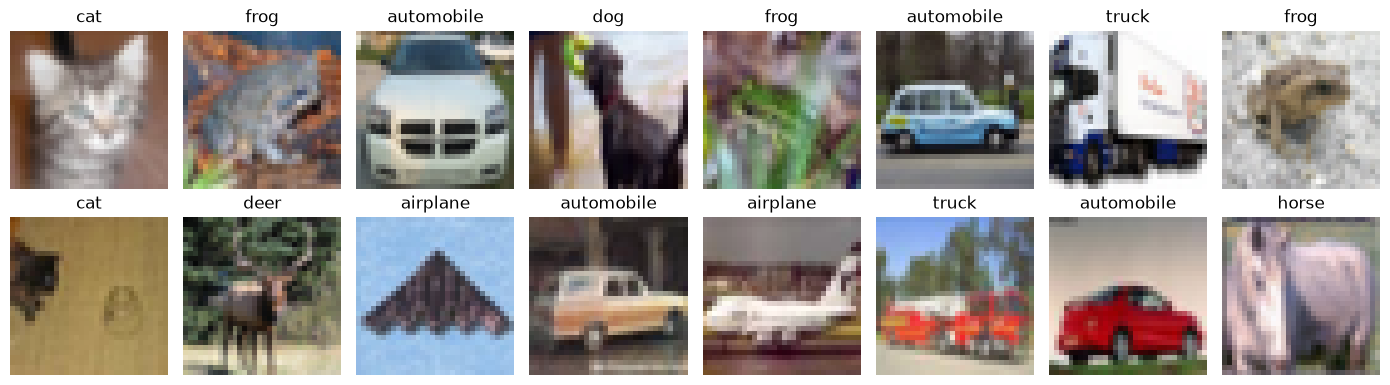

In [5]:
images, labels = next(iter(train_loader))  # un batch : images (128, 3, 32, 32), labels (128,)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, label in zip(axes.flat, images, labels):
    img = img.permute(1, 2, 0).numpy()   # (C, H, W) -> (H, W, C)
    img = img * std + mean               # dénormalisation canal par canal
    img = np.clip(img, 0, 1)             # sécurité pour imshow
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Définition du CNN

Architecture : 3 blocs `Conv2d 3x3 -> ReLU -> MaxPool2d(2)`, puis `Flatten` et deux couches linéaires.

- La convolution 3x3 avec `padding=1` conserve la taille spatiale (H, W) et change le nombre de canaux.
- Le max-pooling 2x2 divise la hauteur et la largeur par 2.
- On double le nombre de canaux à chaque bloc (32 → 64 → 128) pendant que la résolution diminue (32 → 16 → 8 → 4).
- La dernière couche sort 10 scores (logits), un par classe. Pas de softmax ici : `CrossEntropyLoss` l'applique elle-même.

Les commentaires indiquent la forme du tenseur après chaque couche, pour un batch de taille N.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
                                                            # entrée : (N, 3, 32, 32)
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),     # -> (N, 32, 32, 32)
            nn.ReLU(),                                      # -> (N, 32, 32, 32)
            nn.MaxPool2d(2),                                # -> (N, 32, 16, 16)
            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),    # -> (N, 64, 16, 16)
            nn.ReLU(),                                      # -> (N, 64, 16, 16)
            nn.MaxPool2d(2),                                # -> (N, 64, 8, 8)
            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),   # -> (N, 128, 8, 8)
            nn.ReLU(),                                      # -> (N, 128, 8, 8)
            nn.MaxPool2d(2),                                # -> (N, 128, 4, 4)
            # Classifieur
            nn.Flatten(),                                   # -> (N, 128*4*4) = (N, 2048)
            nn.Linear(128 * 4 * 4, 256),                    # -> (N, 256)
            nn.ReLU(),                                      # -> (N, 256)
            nn.Linear(256, num_classes),                    # -> (N, 10)  (logits)
        )

    def forward(self, x):
        return self.net(x)


model = SimpleCNN().to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters())
print(f'Nombre de paramètres : {num_params:,}')

# Petite vérification des dimensions avec un faux batch de 2 images
with torch.no_grad():
    print('Sortie pour une entrée (2, 3, 32, 32) :', model(torch.zeros(2, 3, 32, 32, device=device)).shape)

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=2048, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)
Nombre de paramètres : 620,362
Sortie pour une entrée (2, 3, 32, 32) : torch.Size([2, 10])


## 6. Fonction de perte, optimiseur, et fonctions d'entraînement / d'évaluation

- **Perte** : `CrossEntropyLoss` = softmax + log-vraisemblance négative (la perte softmax du cours CS231n).
- **Optimiseur** : SGD avec momentum 0.9 et learning rate 0.01.

`train_one_epoch` parcourt une fois tout le train : pour chaque batch, forward → calcul de la perte → `zero_grad` → backward → mise à jour des poids.
`evaluate` calcule la perte et l'accuracy moyennes sans calculer de gradients (`torch.no_grad()`).

`model.train()` / `model.eval()` changent le comportement de certaines couches (Dropout, BatchNorm). Notre modèle n'en contient pas, mais c'est une bonne habitude à prendre.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        scores = model(images)              # forward : (N, 10)
        loss = criterion(scores, labels)    # perte moyenne sur le batch

        optimizer.zero_grad()               # remet les gradients à zéro (sinon ils s'accumulent)
        loss.backward()                     # backward : calcule les gradients
        optimizer.step()                    # met à jour les poids

        # Statistiques (on multiplie par la taille du batch pour faire une moyenne exacte à la fin)
        total_loss += loss.item() * images.size(0)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()  # pas de calcul de gradient pendant l'évaluation
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        scores = model(images)
        loss = criterion(scores, labels)

        total_loss += loss.item() * images.size(0)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

## 7. Boucle d'entraînement

On entraîne pendant 10 epochs (une epoch = un passage complet sur les 45 000 images du train). Après chaque epoch, on évalue sur la validation et on stocke les métriques dans des listes pour tracer les courbes ensuite.

Remarque : la train loss affichée est la moyenne *pendant* l'epoch, alors que les poids changent ; elle est donc légèrement pessimiste par rapport à la loss du modèle en fin d'epoch.

In [8]:
NUM_EPOCHS = 10

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'train loss {train_loss:.4f} | train acc {train_acc:.2%} | '
          f'val loss {val_loss:.4f} | val acc {val_acc:.2%}')

Epoch  1/10 | train loss 1.7695 | train acc 35.01% | val loss 1.4655 | val acc 46.44%
Epoch  2/10 | train loss 1.2832 | train acc 53.87% | val loss 1.1391 | val acc 59.20%
Epoch  3/10 | train loss 1.0363 | train acc 63.58% | val loss 0.9930 | val acc 65.12%
Epoch  4/10 | train loss 0.8741 | train acc 69.37% | val loss 0.8874 | val acc 68.04%
Epoch  5/10 | train loss 0.7457 | train acc 73.98% | val loss 0.8115 | val acc 71.42%
Epoch  6/10 | train loss 0.6475 | train acc 77.38% | val loss 0.7751 | val acc 72.50%
Epoch  7/10 | train loss 0.5575 | train acc 80.73% | val loss 0.7355 | val acc 74.06%
Epoch  8/10 | train loss 0.4844 | train acc 82.99% | val loss 0.7502 | val acc 75.06%
Epoch  9/10 | train loss 0.4021 | train acc 85.92% | val loss 0.7839 | val acc 74.82%
Epoch 10/10 | train loss 0.3384 | train acc 88.11% | val loss 0.7867 | val acc 75.98%


## 8. Courbes d'apprentissage

On compare train et validation. Si la loss de train continue de baisser alors que celle de validation stagne ou remonte, le modèle commence à **sur-apprendre** (overfitting).

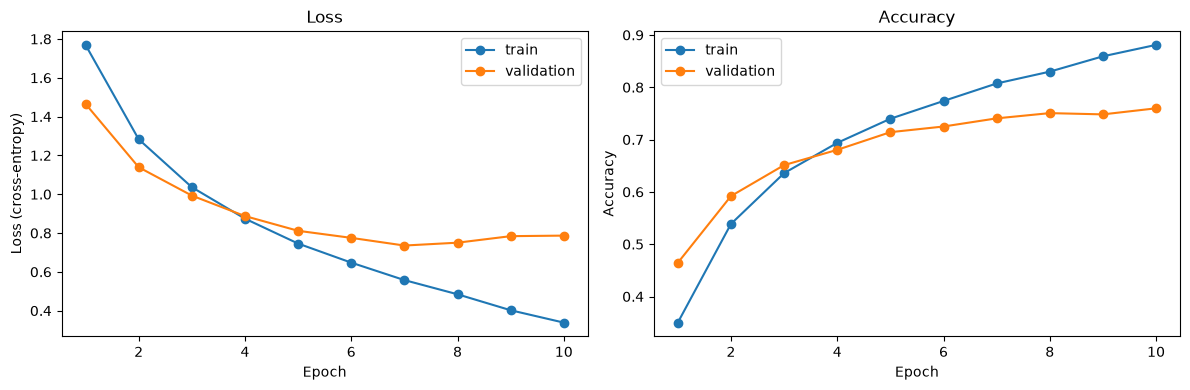

In [9]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, marker='o', label='train')
ax1.plot(epochs, val_losses, marker='o', label='validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (cross-entropy)')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, marker='o', label='train')
ax2.plot(epochs, val_accs, marker='o', label='validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Évaluation finale sur le jeu de test

Le jeu de test (10 000 images) n'a été utilisé ni pour l'entraînement ni pour les choix de modèle : il donne une estimation honnête de la performance sur des images jamais vues.
Pour comparaison, un classifieur au hasard obtiendrait 10 %.

In [10]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test loss : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.2%}')

Test loss : 0.8144
Test accuracy : 75.40%
